# 5.1.2 Model 2: Random Forest Regressor

Trained on `X_train.csv` (unscaled) since tree-based models don't need feature scaling.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (3004, 51) | X_test: (751, 51)


## Hyperparameter Tuning
Tuned with `BayesSearchCV` (continuous search space, `n_iter=50`, 5-fold CV on `X_train`). Since `y_train` is `log(price)` (Section 3.6), a plain RMSE scorer would rank by log-scale error - not guaranteed to match RM-scale RMSE, this project's primary metric (Section 1.8). A custom scorer converts predictions back to RM before scoring.

In [2]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Integer, Real

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)

# Same fold split used by cross_validate_model() (model_utils.py), so the CV score
# BayesSearchCV selects on and the second CV report below are directly comparable.
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "n_estimators": Integer(50, 400),
    "max_depth": Integer(2, 50),
    "min_samples_leaf": Integer(1, 10),
    "max_features": Real(0.1, 1.0),
}

bayes_search = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    search_spaces,
    n_iter=50,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
)
bayes_search.fit(X_train, y_train)

print("Best params:", bayes_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-bayes_search.best_score_:,.0f}")


Best params: OrderedDict({'max_depth': 24, 'max_features': 0.7684211192963937, 'min_samples_leaf': 1, 'n_estimators': 289})
Best CV score (RM-scale RMSE): RM 160,489


## 5-fold Cross-Validation
Run on `X_train` only, using `bayes_search.best_params_`. `X_test` is not touched here.

In [3]:
cv_results = cross_validate_model(
    RandomForestRegressor(**bayes_search.best_params_, random_state=42),
    X_train, y_train, n_splits=5,
)


5-fold CV (mean +/- std):
  RMSE:  RM 160,489 +/- 28,693  (45.6% of median price)
  MAE:   RM 76,586 +/- 4,326
  MAPE:  18.8% +/- 1.2%
  R2:    0.7556 +/- 0.0491


## Train Final Model
`BayesSearchCV`'s `refit=True` already retrained the best config on the full `X_train` (`bayes_search.best_estimator_`), reused directly here. `X_test` is touched only once, below.

In [4]:
final_params = bayes_search.best_params_
model = bayes_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from BayesSearchCV's refit=True).")


Final params: OrderedDict({'max_depth': 24, 'max_features': 0.7684211192963937, 'min_samples_leaf': 1, 'n_estimators': 289})
Model ready (reused from BayesSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")


Train RMSE:  RM 71,540  (20.4% of median price)
Train MAE:   RM 29,565
Train MAPE:  6.6%
Train R2:    0.9524

Test RMSE:  RM 175,825  (48.8% of median price)
Test MAE:   RM 76,856
Test MAPE:  16.3%
Test R2:    0.7191


## Feature Importance vs EDA (Section 4.5.2)
Checks whether Random Forest's importances agree with Section 4.5.2's EDA findings (Property Size, Bathroom, Parking Lot, Has_Gymnasium/Has_Swimming_Pool as top numerical correlates; Property Type and State as strong categorical predictors).

In [6]:
importance_table = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features by importance:")
print(importance_table.head(15))


Top 15 features by importance:
Property Size                     0.464107
Has_Gymnasium                     0.050878
Parking Lot                       0.044950
State_Penang                      0.041184
PropertyType_Condominium          0.033652
Bathroom                          0.029333
# of Floors                       0.027907
Property Age                      0.027340
PropertyType_Flat                 0.026456
Has_Security                      0.025626
State_Selangor                    0.023680
Total Units                       0.022191
PropertyType_Service_Residence    0.022128
Listed_Facility_Count             0.019270
Bedroom                           0.011330
dtype: float64


## Save Trained Model
Saved for the Streamlit prototype (Section 8) to load directly, without retraining.

In [7]:
import joblib
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, "random_forest_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\random_forest_model.pkl


## Hyperparameter Sensitivity Visualizations (Diagnostic)
Each hyperparameter is swept individually, holding the other three at their `BayesSearchCV`-selected values, using 5-fold CV RMSE. Diagnostic only - not used for selection.

## Visualizing the max_depth Trade-off
`max_depth` swept across the searched range (others fixed at final values), evaluated with Train and CV RMSE. `None` is included as a reference point outside the searched range (`Integer(2, 50)`).

5-fold CV (mean +/- std):
  RMSE:  RM 184,925 +/- 30,344  (52.6% of median price)
  MAE:   RM 95,381 +/- 5,507
  MAPE:  23.3% +/- 1.2%
  R2:    0.6770 +/- 0.0501


5-fold CV (mean +/- std):
  RMSE:  RM 164,356 +/- 30,276  (46.7% of median price)
  MAE:   RM 80,628 +/- 4,522
  MAPE:  19.9% +/- 1.2%
  R2:    0.7441 +/- 0.0520


5-fold CV (mean +/- std):
  RMSE:  RM 161,419 +/- 29,718  (45.9% of median price)
  MAE:   RM 77,295 +/- 4,359
  MAPE:  18.9% +/- 1.3%
  R2:    0.7533 +/- 0.0496


5-fold CV (mean +/- std):
  RMSE:  RM 162,381 +/- 29,067  (46.2% of median price)
  MAE:   RM 76,805 +/- 4,144
  MAPE:  18.8% +/- 1.3%
  R2:    0.7500 +/- 0.0493


5-fold CV (mean +/- std):
  RMSE:  RM 162,892 +/- 30,788  (46.3% of median price)
  MAE:   RM 77,153 +/- 4,294
  MAPE:  18.8% +/- 1.3%
  R2:    0.7483 +/- 0.0544


5-fold CV (mean +/- std):
  RMSE:  RM 162,941 +/- 30,930  (46.3% of median price)
  MAE:   RM 77,105 +/- 4,272
  MAPE:  18.8% +/- 1.3%
  R2:    0.7482 +/- 0.0547


5-fold CV (mean +/- std):
  RMSE:  RM 162,941 +/- 30,930  (46.3% of median price)
  MAE:   RM 77,105 +/- 4,272
  MAPE:  18.8% +/- 1.3%
  R2:    0.7482 +/- 0.0547


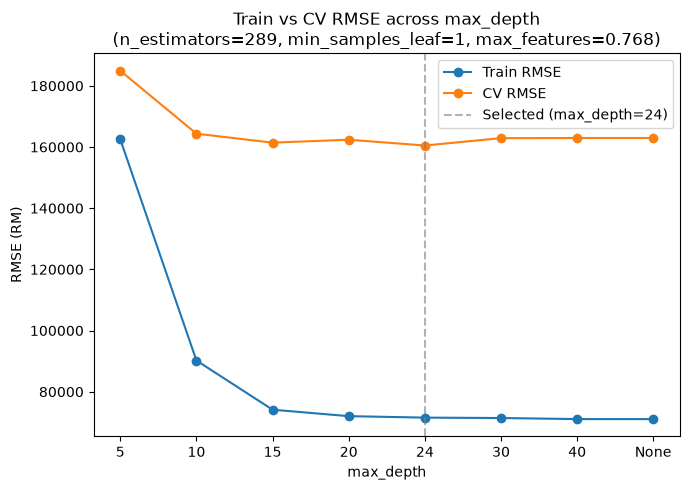

max_depth=5: Train RMSE=RM162,523  CV RMSE=RM184,925
max_depth=10: Train RMSE=RM90,209  CV RMSE=RM164,356
max_depth=15: Train RMSE=RM74,127  CV RMSE=RM161,419
max_depth=20: Train RMSE=RM72,017  CV RMSE=RM162,381
max_depth=24: Train RMSE=RM71,540  CV RMSE=RM160,489
max_depth=30: Train RMSE=RM71,404  CV RMSE=RM162,892
max_depth=40: Train RMSE=RM71,060  CV RMSE=RM162,941
max_depth=None: Train RMSE=RM71,060  CV RMSE=RM162,941


In [8]:
import matplotlib.pyplot as plt

best = bayes_search.best_params_
depth_candidates = sorted({5, 10, 15, 20, 30, 40, best["max_depth"]}) + [None]
train_rmse_by_depth = []
cv_rmse_by_depth = []

for d in depth_candidates:
    if d == best["max_depth"]:
        train_rmse_by_depth.append(train_metrics["RMSE"])
        cv_rmse_by_depth.append(cv_results["mean"]["RMSE"])
        continue
    m = RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=d, min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42)
    m.fit(X_train, y_train)
    train_rmse_by_depth.append(evaluate_model(m, X_train, y_train)["RMSE"])
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=d, min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_depth.append(cv["mean"]["RMSE"])

depth_labels = ["None" if d is None else str(d) for d in depth_candidates]
selected_label = "None" if best["max_depth"] is None else str(best["max_depth"])

plt.figure(figsize=(7, 5))
plt.plot(depth_labels, train_rmse_by_depth, marker="o", label="Train RMSE")
plt.plot(depth_labels, cv_rmse_by_depth, marker="o", label="CV RMSE")
plt.axvline(x=depth_labels.index(selected_label), color="grey", linestyle="--", alpha=0.6, label=f"Selected (max_depth={selected_label})")
plt.xlabel("max_depth")
plt.ylabel("RMSE (RM)")
plt.title(f"Train vs CV RMSE across max_depth\n(n_estimators={best['n_estimators']}, min_samples_leaf={best['min_samples_leaf']}, max_features={best['max_features']:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

for d, tr, cv_r in zip(depth_labels, train_rmse_by_depth, cv_rmse_by_depth):
    print(f"max_depth={d}: Train RMSE=RM{tr:,.0f}  CV RMSE=RM{cv_r:,.0f}")


## Visualizing the max_features Effect
`max_features` swept across `Real(0.1, 1.0)` (others fixed). `sqrt` included as a reference point.

5-fold CV (mean +/- std):
  RMSE:  RM 196,122 +/- 40,631  (55.7% of median price)
  MAE:   RM 82,046 +/- 7,056
  MAPE:  19.0% +/- 1.4%
  R2:    0.6411 +/- 0.0679


5-fold CV (mean +/- std):
  RMSE:  RM 177,520 +/- 36,477  (50.5% of median price)
  MAE:   RM 78,361 +/- 5,901
  MAPE:  18.6% +/- 1.3%
  R2:    0.7052 +/- 0.0581


5-fold CV (mean +/- std):
  RMSE:  RM 167,717 +/- 33,411  (47.7% of median price)
  MAE:   RM 77,332 +/- 5,274
  MAPE:  18.7% +/- 1.3%
  R2:    0.7354 +/- 0.0544


5-fold CV (mean +/- std):
  RMSE:  RM 167,177 +/- 25,637  (47.5% of median price)
  MAE:   RM 77,720 +/- 3,243
  MAPE:  19.1% +/- 1.5%
  R2:    0.7295 +/- 0.0688


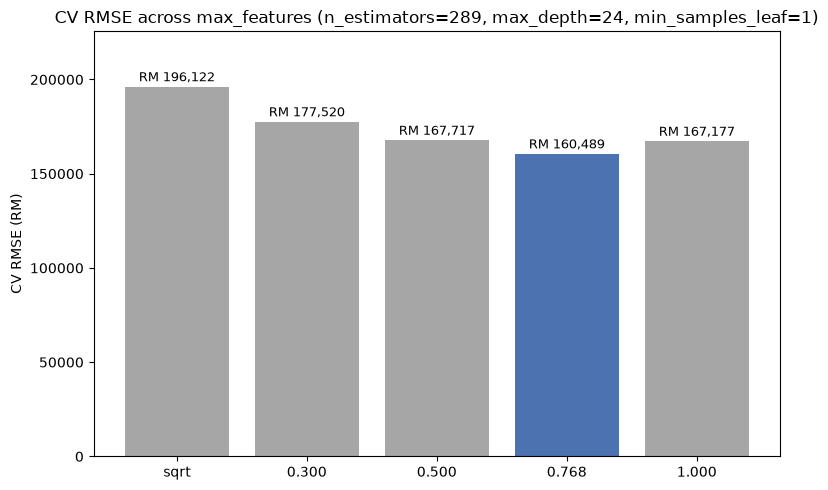

max_features=sqrt: CV RMSE=RM196,122
max_features=0.300: CV RMSE=RM177,520
max_features=0.500: CV RMSE=RM167,717
max_features=0.768: CV RMSE=RM160,489
max_features=1.000: CV RMSE=RM167,177


In [9]:
best = bayes_search.best_params_
feature_candidates = ["sqrt", 0.3, 0.5, best["max_features"], 1.0]
cv_rmse_by_feat = []

for f in feature_candidates:
    if f == best["max_features"]:
        cv_rmse_by_feat.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=best["max_depth"], min_samples_leaf=best["min_samples_leaf"], max_features=f, random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_feat.append(cv["mean"]["RMSE"])

feature_labels = [f if isinstance(f, str) else f"{f:.3f}" for f in feature_candidates]
colors = ["#4c72b0" if f == best["max_features"] else "#a6a6a6" for f in feature_candidates]

plt.figure(figsize=(8, 5))
plt.bar(feature_labels, cv_rmse_by_feat, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across max_features (n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, min_samples_leaf={best['min_samples_leaf']})")
plt.ylim(0, max(cv_rmse_by_feat) * 1.15)
for i, v in enumerate(cv_rmse_by_feat):
    plt.text(i, v + max(cv_rmse_by_feat) * 0.015, f"RM {v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for f, r in zip(feature_labels, cv_rmse_by_feat):
    print(f"max_features={f}: CV RMSE=RM{r:,.0f}")


## Visualizing the n_estimators Effect
`n_estimators` swept across `Integer(50, 400)` (others fixed at final `BayesSearchCV` values).

5-fold CV (mean +/- std):
  RMSE:  RM 162,473 +/- 28,194  (46.2% of median price)
  MAE:   RM 77,386 +/- 4,184
  MAPE:  19.0% +/- 1.1%
  R2:    0.7500 +/- 0.0473


5-fold CV (mean +/- std):
  RMSE:  RM 160,437 +/- 27,801  (45.6% of median price)
  MAE:   RM 76,918 +/- 4,456
  MAPE:  18.9% +/- 1.2%
  R2:    0.7561 +/- 0.0460


5-fold CV (mean +/- std):
  RMSE:  RM 160,372 +/- 28,913  (45.6% of median price)
  MAE:   RM 76,644 +/- 4,400
  MAPE:  18.8% +/- 1.2%
  R2:    0.7563 +/- 0.0489


5-fold CV (mean +/- std):
  RMSE:  RM 160,175 +/- 28,639  (45.5% of median price)
  MAE:   RM 76,593 +/- 4,386
  MAPE:  18.8% +/- 1.2%
  R2:    0.7569 +/- 0.0479


5-fold CV (mean +/- std):
  RMSE:  RM 160,476 +/- 28,681  (45.6% of median price)
  MAE:   RM 76,567 +/- 4,301
  MAPE:  18.8% +/- 1.2%
  R2:    0.7557 +/- 0.0490


5-fold CV (mean +/- std):
  RMSE:  RM 161,365 +/- 28,978  (45.9% of median price)
  MAE:   RM 76,612 +/- 4,282
  MAPE:  18.8% +/- 1.2%
  R2:    0.7529 +/- 0.0500


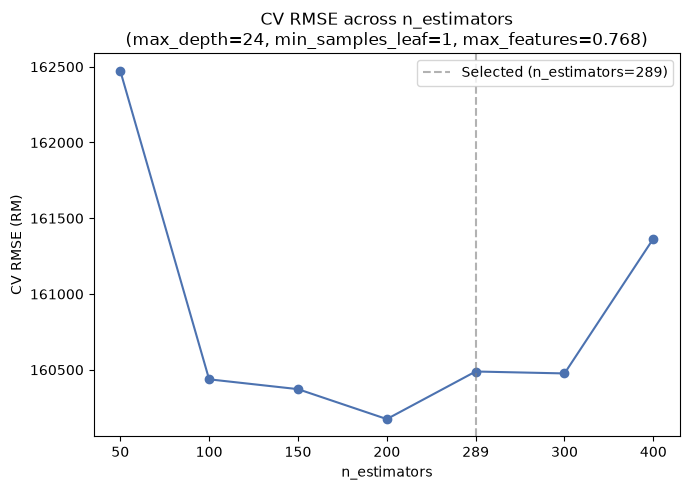

n_estimators=50: CV RMSE=RM162,473
n_estimators=100: CV RMSE=RM160,437
n_estimators=150: CV RMSE=RM160,372
n_estimators=200: CV RMSE=RM160,175
n_estimators=289: CV RMSE=RM160,489
n_estimators=300: CV RMSE=RM160,476
n_estimators=400: CV RMSE=RM161,365


In [10]:
best = bayes_search.best_params_
n_estimators_candidates = sorted({50, 100, 150, 200, 300, 400, best["n_estimators"]})
cv_rmse_by_n = []

for n in n_estimators_candidates:
    if n == best["n_estimators"]:
        cv_rmse_by_n.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=n, max_depth=best["max_depth"], min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_n.append(cv["mean"]["RMSE"])

n_labels = [str(n) for n in n_estimators_candidates]
plt.figure(figsize=(7, 5))
plt.plot(n_labels, cv_rmse_by_n, marker="o", color="#4c72b0")
plt.axvline(x=n_labels.index(str(best["n_estimators"])), color="grey", linestyle="--", alpha=0.6, label=f"Selected (n_estimators={best['n_estimators']})")
plt.xlabel("n_estimators")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across n_estimators\n(max_depth={best['max_depth']}, min_samples_leaf={best['min_samples_leaf']}, max_features={best['max_features']:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

for n, r in zip(n_estimators_candidates, cv_rmse_by_n):
    print(f"n_estimators={n}: CV RMSE=RM{r:,.0f}")


## Checking the min_samples_leaf Effect
`min_samples_leaf` swept across `Integer(1, 10)` (others fixed).

5-fold CV (mean +/- std):
  RMSE:  RM 164,737 +/- 29,161  (46.8% of median price)
  MAE:   RM 78,164 +/- 4,308
  MAPE:  19.1% +/- 1.3%
  R2:    0.7432 +/- 0.0480


5-fold CV (mean +/- std):
  RMSE:  RM 168,431 +/- 30,202  (47.9% of median price)
  MAE:   RM 79,930 +/- 4,895
  MAPE:  19.5% +/- 1.3%
  R2:    0.7327 +/- 0.0458


5-fold CV (mean +/- std):
  RMSE:  RM 176,218 +/- 32,422  (50.1% of median price)
  MAE:   RM 83,540 +/- 5,500
  MAPE:  20.2% +/- 1.3%
  R2:    0.7089 +/- 0.0464


5-fold CV (mean +/- std):
  RMSE:  RM 184,732 +/- 34,419  (52.5% of median price)
  MAE:   RM 86,800 +/- 5,836
  MAPE:  20.8% +/- 1.3%
  R2:    0.6809 +/- 0.0486


5-fold CV (mean +/- std):
  RMSE:  RM 195,361 +/- 36,192  (55.5% of median price)
  MAE:   RM 90,235 +/- 6,336
  MAPE:  21.4% +/- 1.4%
  R2:    0.6436 +/- 0.0509


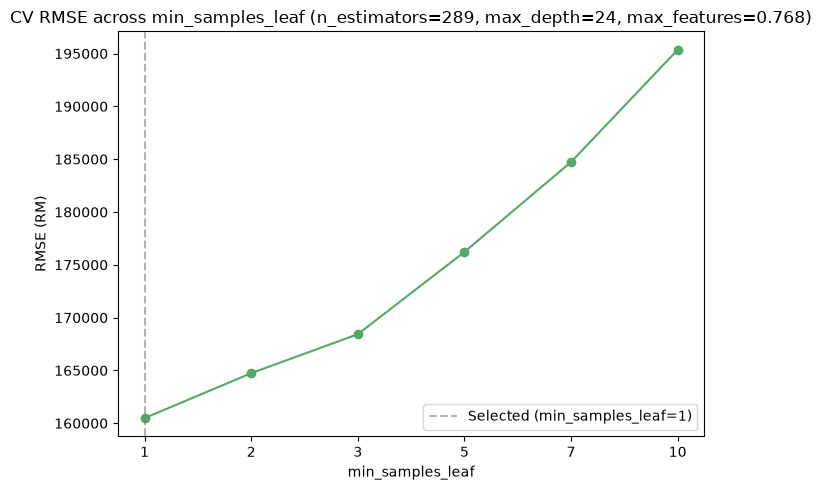

min_samples_leaf=1: CV RMSE=RM160,489
min_samples_leaf=2: CV RMSE=RM164,737
min_samples_leaf=3: CV RMSE=RM168,431
min_samples_leaf=5: CV RMSE=RM176,218
min_samples_leaf=7: CV RMSE=RM184,732
min_samples_leaf=10: CV RMSE=RM195,361


In [11]:
best = bayes_search.best_params_
leaf_candidates = sorted({1, 2, 3, 5, 7, 10, best["min_samples_leaf"]})
cv_rmse_by_leaf = []

for l in leaf_candidates:
    if l == best["min_samples_leaf"]:
        cv_rmse_by_leaf.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=best["max_depth"], min_samples_leaf=l, max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_leaf.append(cv["mean"]["RMSE"])

leaf_labels = [str(l) for l in leaf_candidates]
plt.figure(figsize=(7, 5))
plt.plot(leaf_labels, cv_rmse_by_leaf, marker="o", color="#55a868")
plt.axvline(x=leaf_labels.index(str(best["min_samples_leaf"])), color="grey", linestyle="--", alpha=0.6, label=f"Selected (min_samples_leaf={best['min_samples_leaf']})")
plt.xlabel("min_samples_leaf")
plt.ylabel("RMSE (RM)")
plt.title(f"CV RMSE across min_samples_leaf (n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, max_features={best['max_features']:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

for l, r in zip(leaf_candidates, cv_rmse_by_leaf):
    print(f"min_samples_leaf={l}: CV RMSE=RM{r:,.0f}")
